Saving Thermal_Throttling_FINAL.xlsx to Thermal_Throttling_FINAL (1).xlsx
        OS  Run_ID  Temperature_C  Baseline_Performance  Thermal_Performance  \
0  Windows       1             40                    99                96.03   
1  Windows       2             40                   100                97.00   
2  Windows       3             40                   101                97.97   
3  Windows       4             40                    99                96.03   
4  Windows       5             40                   100                97.00   

   Performance_Degradation_pct  
0                            3  
1                            3  
2                            3  
3                            3  
4                            3  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   OS                      

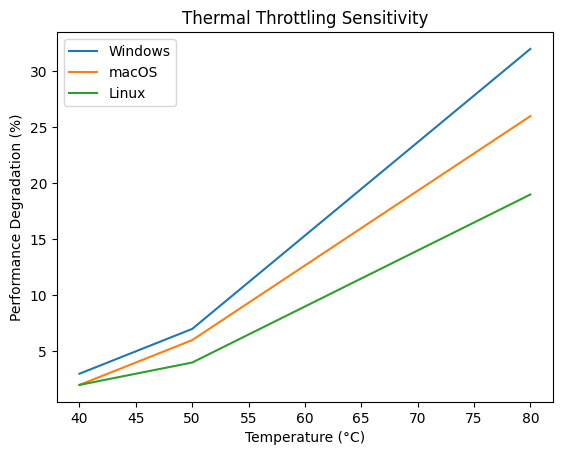

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print(df.head())
print(df.info())

grouped = df.groupby(["OS", "Temperature_C"])["Performance_Degradation_pct"].mean()
pivot = grouped.unstack()

print(pivot)

temps = [40, 50, 80]

windows = pivot.loc["Windows"].values
macos = pivot.loc["macOS"].values
linux = pivot.loc["Linux"].values

plt.figure()

plt.plot(temps, windows, label="Windows")
plt.plot(temps, macos, label="macOS")
plt.plot(temps, linux, label="Linux")

plt.legend()
plt.title("Thermal Throttling Sensitivity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Performance Degradation (%)")

plt.show()